In [5]:
import sys, os
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_poisson_deviance, make_scorer
from preprocessing.preprocessing_utils import preprocess_for_tree

In [6]:
# Data Loading and Preprocessing


train = pd.read_csv("../data/claims_train.csv")
test  = pd.read_csv("../data/claims_test.csv")

# Preprocess
X_tr, y_tr_rate, w_tr = preprocess_for_tree(train)
X_te, y_te_rate, w_te = preprocess_for_tree(test)
feature_names = list(X_tr.columns) 
print(f"Feature names extracted: {feature_names}")

# Convert to numpy for sklearn efficiency
X_train = X_tr.values.astype(np.float32)
y_train = y_tr_rate.values.astype(np.float32)
w_train = w_tr.values.astype(np.float32)

X_test = X_te.values.astype(np.float32)
y_test = y_te_rate.values.astype(np.float32)
w_test = w_te.values.astype(np.float32)

print(f"Training Shape: {X_tr.shape}")
print(f"Testing Shape:  {X_test.shape}")

Feature names extracted: ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area_Int', 'VehBrand_B10', 'VehBrand_B11', 'VehBrand_B12', 'VehBrand_B13', 'VehBrand_B14', 'VehBrand_B2', 'VehBrand_B3', 'VehBrand_B4', 'VehBrand_B5', 'VehBrand_B6', 'VehGas_Regular', 'Region_R21', 'Region_R22', 'Region_R23', 'Region_R24', 'Region_R25', 'Region_R26', 'Region_R31', 'Region_R41', 'Region_R42', 'Region_R43', 'Region_R52', 'Region_R53', 'Region_R54', 'Region_R72', 'Region_R73', 'Region_R74', 'Region_R82', 'Region_R83', 'Region_R91', 'Region_R93', 'Region_R94']
Training Shape: (542410, 38)
Testing Shape:  (135603, 38)


In [7]:

# EVALUATION METRICS

def d_squared_poisson(y_true, y_pred, w):
    """Calculates D^2  and prints the Model Deviance and Null Deviance explicitly."""
    #  Deviance of the model
    dev_model = mean_poisson_deviance(y_true, y_pred, sample_weight=w)
    
    # Intercept only
    mu = np.average(y_true, weights=w)
    y_null = np.full_like(y_true, mu)
    dev_null = mean_poisson_deviance(y_true, y_null, sample_weight=w)
    
    # D^2
    d2 = 1 - (dev_model / dev_null)
    
    
    print(f"D^2 Calculation")
    print(f"Null Deviance (Baseline): {dev_null:.5f}")
    print(f"Model Deviance:           {dev_model:.5f}")
    print(f"D^2 Score:                {d2:.2%}")
    print(f"-----------------------")
    
    return d2

def plot_lorenz_curve(y_true, y_pred, w, title="Lorenz Curve"):
    """Gini coefficient visualization. Prints AUC and Gini values."""
    
    # Sort by predicted risk
    data = pd.DataFrame({'True': y_true, 'Pred': y_pred, 'Weight': w})
    data = data.sort_values('Pred')
    
    # Cumulative distributions
    data['CumExposure'] = data['Weight'].cumsum() / data['Weight'].sum()
    data['CumClaims'] = (data['True'] * data['Weight']).cumsum() / (data['True'] * data['Weight']).sum()
    
    # Gini Calculation
    auc = np.trapz(data['CumClaims'], data['CumExposure'])
    gini = 1 - 2 * auc 
    
    
    print(f"--- Gini Calculation ---")
    print(f"Area Under Curve (AUC): {auc:.5f}")
    print(f"Gini Coefficient:       {gini:.5f}")
    print(f"------------------------")
    
    
    plt.figure(figsize=(6, 6))
    plt.plot(data['CumExposure'], data['CumClaims'], label=f'Model (Gini: {gini:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random (Gini: 0.0)')
    plt.xlabel('Cumulative Exposure (sorted by Pred Risk)')
    plt.ylabel('Cumulative Actual Claims')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return gini

def plot_calibration(y_true, y_pred, w, n_bins=10, title="Calibration Plot"):
    """ Splits the data into risk bins, compares Average Predicted Risk vs Average Actual Risk.Prints values"""
    data = pd.DataFrame({'True': y_true, 'Pred': y_pred, 'Weight': w})
    
    #Binning, handles cases with many identical predictions
    try:
        data['Bin'] = pd.qcut(data['Pred'], n_bins, duplicates='drop')
    except:
        data['Bin'] = pd.cut(data['Pred'], n_bins)
        
    # Calculate Weighted Averages for each bin
    grouped = data.groupby('Bin', observed=False).apply(
        lambda x: pd.Series({
            'AvgPred': np.average(x['Pred'], weights=x['Weight']),
            'AvgTrue': np.average(x['True'], weights=x['Weight']),
            'Exposure': x['Weight'].sum(),
            'Count': len(x)
        })
    )
    
   
    print(f"\n---{title} Data ---")
    
    print_df = grouped.copy()
    print_df['Diff'] = print_df['AvgPred'] - print_df['AvgTrue']
    print_df['Error %'] = (print_df['Diff'] / print_df['AvgTrue']) * 100
    
    
    print(print_df[['AvgPred', 'AvgTrue', 'Diff', 'Exposure']].to_string(float_format="%.4f"))
    print("------------------------------------------------\n")
    
    
   
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(grouped))
    width = 0.35
    
    ax1.bar(x - width/2, grouped['AvgPred'], width, label='Predicted Rate', alpha=0.8, color='teal')
    ax1.bar(x + width/2, grouped['AvgTrue'], width, label='Actual Rate', alpha=0.7, color='slategrey')
    
    ax1.set_xlabel('Risk Groups (Low -> High)')
    ax1.set_ylabel('Claim Rate')
    ax1.set_title(title)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{i+1}" for i in x])
    ax1.legend(loc='upper left')
    
    ax2 = ax1.twinx()
    ax2.plot(x, grouped['Exposure'], color='red', linestyle='--', marker='o', label='Exposure Vol', alpha=0.3)
    ax2.set_ylabel('Total Exposure (Years)')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, title="Feature Importance"):
    """Visualizes and prints which features the LightGBM model relies on most"""

    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
   
    print(f"\n--- {title} Scores ---")
    print(f"{'Rank':<5} {'Feature':<20} {'Importance':<10}")
    print("-" * 40)
    
    top_n = min(15, len(feature_names))
    for i in range(top_n):
        idx = indices[i]
        print(f"{i+1:<5} {feature_names[idx]:<20} {importances[idx]:.5f}")
    print("--------------------------------\n")
    
    
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.bar(range(top_n), importances[indices[:top_n]], align="center")
    plt.xticks(range(top_n), [feature_names[i] for i in indices[:top_n]], rotation=45, ha='right')
    plt.xlabel("Feature")
    plt.ylabel("Importance Score (Gain)")
    plt.tight_layout()
    plt.show()

In [8]:

# Hyperparameter Tuning 
# We use a higher learning rate here (0.05) to find the best tree structure quickly

# Define the parameter grid to test ranges
param_grid = {
    'num_leaves': [31, 50, 70],  
    'min_child_samples': [20, 50, 100, 200], 
    'subsample': [0.6, 0.8, 1.0],    
    'colsample_bytree': [0.6, 0.8, 1.0], 
    'reg_alpha': [0, 0.1, 1.0, 5.0],  
    'reg_lambda': [0, 0.1, 1.0, 5.0]  
}

# Setup the Base Model
lgbm = lgb.LGBMRegressor(
    objective='poisson', 
    metric='poisson',
    learning_rate=0.05,      
    n_estimators=500,       
    verbosity=-1, 
    random_state=7,
    n_jobs=-1
)

# Setup Random Search
print("Starting Hyperparameter Tuning...")
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_mean_poisson_deviance",
    cv=3,                   
    verbose=1,
    random_state=7
)

#Run the search
random_search.fit(X_tr, y_train, sample_weight=w_train)

print(f"Best Parameters: {random_search.best_params_}")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'num_leaves': 70, 'min_child_samples': 20, 'colsample_bytree': 0.6}


In [9]:

# High-Performance Ensemble, applying  best params and slow Learning
# Now we take the 'best_params_' from above, lower the learning rate,and train the robust ensemble.

#Extract best params and update for slow learning
params = random_search.best_params_.copy()

# Add/Override specific settings for the final slow training
params.update({
    'objective': 'poisson',
    'metric': 'poisson',
    'learning_rate': 0.005,       
    'n_jobs': -1,
    'verbosity': -1,
    'random_state': 7
})

# Prepare for Ensembling
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=7)

y_pred_ensemble = np.zeros(len(X_test))
models = []

print(f"\nStarting {n_folds}-Fold Ensemble Training with BEST parameters...")

# Train Ensemble
for fold, (train_idx, val_idx) in enumerate(kf.split(X_tr, y_train)):
    print(f"--- Fold {fold+1} / {n_folds} ---")
    
    # Create Fold Data
    X_t = X_tr.iloc[train_idx]
    y_t = y_train[train_idx]
    w_t = w_train[train_idx]
    
    X_v = X_tr.iloc[val_idx]
    y_v = y_train[val_idx]
    w_v = w_train[val_idx]
    
    # Create Datasets
    dtrain = lgb.Dataset(X_t, label=y_t, weight=w_t)
    dval = lgb.Dataset(X_v, label=y_v, weight=w_v, reference=dtrain)
    
    # Train
    model = lgb.train(
        params,
        dtrain,
        num_boost_round=10000,           
        valid_sets=[dtrain, dval],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=1000) 
        ]
    )
    
    models.append(model)
    
    # Predict
    y_pred_ensemble += model.predict(X_test) / n_folds

print("\nEnsemble Training Complete!")


Starting 5-Fold Ensemble Training with BEST parameters...
--- Fold 1 / 5 ---
Training until validation scores don't improve for 100 rounds
[1000]	train's poisson: 0.302123	valid's poisson: 0.308263
[2000]	train's poisson: 0.297279	valid's poisson: 0.306659
[3000]	train's poisson: 0.294025	valid's poisson: 0.306285
[4000]	train's poisson: 0.291343	valid's poisson: 0.306157
[5000]	train's poisson: 0.288909	valid's poisson: 0.30603
Early stopping, best iteration is:
[5628]	train's poisson: 0.287474	valid's poisson: 0.30599
--- Fold 2 / 5 ---
Training until validation scores don't improve for 100 rounds
[1000]	train's poisson: 0.302772	valid's poisson: 0.304619
[2000]	train's poisson: 0.297899	valid's poisson: 0.302971
[3000]	train's poisson: 0.294717	valid's poisson: 0.302601
[4000]	train's poisson: 0.292004	valid's poisson: 0.3024
[5000]	train's poisson: 0.28955	valid's poisson: 0.302245
[6000]	train's poisson: 0.287245	valid's poisson: 0.302135
[7000]	train's poisson: 0.285133	valid's 

D^2 Calculation
Null Deviance (Baseline): 0.63304
Model Deviance:           0.57073
D^2 Score:                9.84%
-----------------------
--- Gini Calculation ---
Area Under Curve (AUC): 0.31896
Gini Coefficient:       0.36209
------------------------


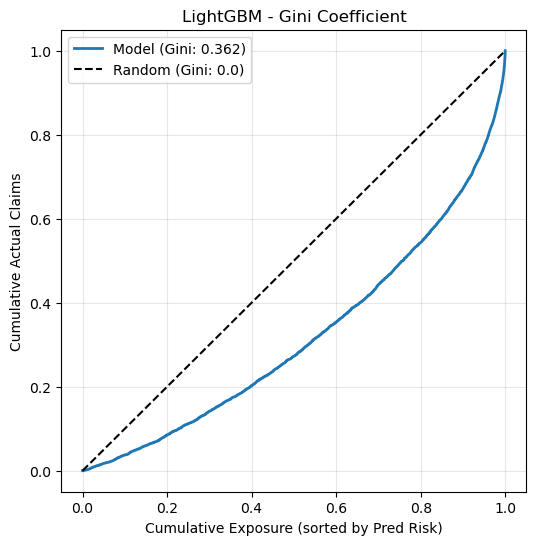

C:\Users\Emil\AppData\Local\Temp\ipykernel_4268\2064703733.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = data.groupby('Bin', observed=False).apply(



---Calibration Plot Data ---
                  AvgPred  AvgTrue    Diff  Exposure
Bin                                                 
(0.0098, 0.0485]   0.0394   0.0400 -0.0006 8398.8867
(0.0485, 0.059]    0.0540   0.0495  0.0045 7775.4365
(0.059, 0.0673]    0.0633   0.0593  0.0040 7676.3765
(0.0673, 0.0748]   0.0711   0.0649  0.0062 7640.4829
(0.0748, 0.0819]   0.0783   0.0788 -0.0005 7791.5620
(0.0819, 0.0898]   0.0857   0.0814  0.0043 7861.1792
(0.0898, 0.101]    0.0949   0.1006 -0.0057 7238.1768
(0.101, 0.126]     0.1118   0.1115  0.0004 6342.0244
(0.126, 0.192]     0.1518   0.1601 -0.0083 5871.8379
(0.192, 6.745]     0.3689   0.3950 -0.0260 5030.9004
------------------------------------------------



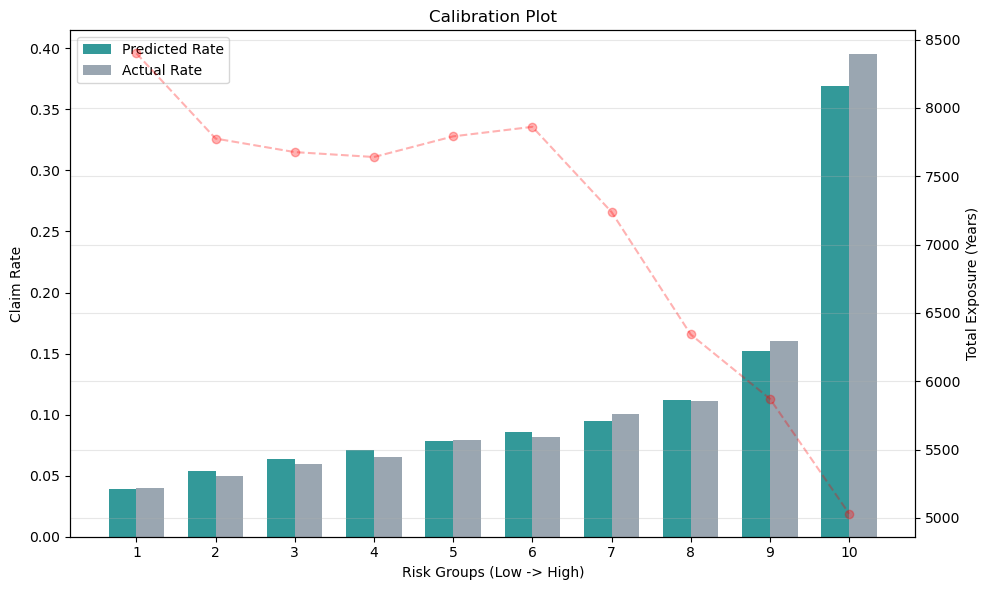

In [11]:

#  FINAL MODEL AND EVALUATIO

# Metrics
test_deviance = mean_poisson_deviance(y_test, y_pred_ensemble, sample_weight=w_test)
d2_score = d_squared_poisson(y_test, y_pred_ensemble, w_test)

# Lorenz curve 
plot_lorenz_curve(y_test, y_pred_ensemble, w_test, title="LightGBM - Gini Coefficient")

# Calibration plot
plot_calibration(y_test, y_pred_ensemble, w_test)

# Feature Importance
# plot_feature_importance(models[0], feature_names, title="GBM Feature Importance ")